# Session 3 — Sentence-Level Analysis
## Measure 1: Sentence Length & Distribution
This notebook helps you split your text into sentences and compute:
- number of sentences
- average sentence length (in tokens and in characters)
- distribution / histogram of sentence lengths
- comparison across two texts/authors

Like before, we'll analyze Lewis Carroll's two Alice books as our example texts:
- Alice's Adventures in Wonderland
- Through the Looking-Glass

In [1]:
#test123

import re
from collections import Counter
import matplotlib.pyplot as plt

# Load the Alice books from Project Gutenberg
def load_book(filepath):
    """Load and clean book text from Project Gutenberg"""
    with open(filepath, 'r', encoding='utf-8') as f:
        text = f.read()
    
    # Remove Project Gutenberg headers/footers
    # Find start of actual content
    if 'CHAPTER I' in text:
        start = text.find('CHAPTER I')
        text = text[start:]
    elif '*** START OF' in text:
        start = text.find('*** START OF')
        text = text[start + 100:]  # Skip the marker line
    
    # Remove end markers
    if '*** END OF' in text:
        end = text.find('*** END OF')
        text = text[:end]
    elif 'End of Project Gutenberg' in text:
        end = text.find('End of Project Gutenberg')
        text = text[:end]
    
    return text.strip()

# Load both Alice books
crime_text = load_book('../data/Crime-punishment.txt')
brothers_text = load_book('../data/The-BrothersKaramazov.txt')

print(f"Crime and Punishment: {len(crime_text):,} characters")
print(f"The Brothers Karamazov: {len(brothers_text):,} characters")

Crime and Punishment: 1,224,428 characters
The Brothers Karamazov: 1,956,237 characters


In [2]:
# Analyze sentence length for both books
def analyze_sentences(text, book_name):
    """Split text into sentences and analyze lengths"""
    # Split on sentence boundaries
    sentences = re.split(r'[.!?]+\s+', text.strip())
    sentences = [s.strip() for s in sentences if s.strip() and len(s.split()) > 2]
    
    lengths_tokens = [len(s.split()) for s in sentences]
    lengths_chars = [len(s) for s in sentences]
    
    print(f"\n{'='*70}")
    print(f"{book_name}")
    print(f"{'='*70}")
    print(f"Number of sentences: {len(sentences):,}")
    print(f"Avg sentence length (tokens): {sum(lengths_tokens)/len(lengths_tokens):.2f}")
    print(f"Avg sentence length (chars): {sum(lengths_chars)/len(lengths_chars):.2f}")
    print(f"Min sentence length (tokens): {min(lengths_tokens)}")
    print(f"Max sentence length (tokens): {max(lengths_tokens)}")
    
    return sentences, lengths_tokens, lengths_chars

# Analyze both books
crime_sents, crime_tokens, crime_chars = analyze_sentences(crime_text, "Crime and Punishment")
brothers_sents, brothers_tokens, brothers_chars = analyze_sentences(brothers_text, "The Brothers Karamazov")


Crime and Punishment
Number of sentences: 12,802
Avg sentence length (tokens): 16.45
Avg sentence length (chars): 91.47
Min sentence length (tokens): 3
Max sentence length (tokens): 271

The Brothers Karamazov
Number of sentences: 18,790
Avg sentence length (tokens): 18.63
Avg sentence length (chars): 101.24
Min sentence length (tokens): 3
Max sentence length (tokens): 212


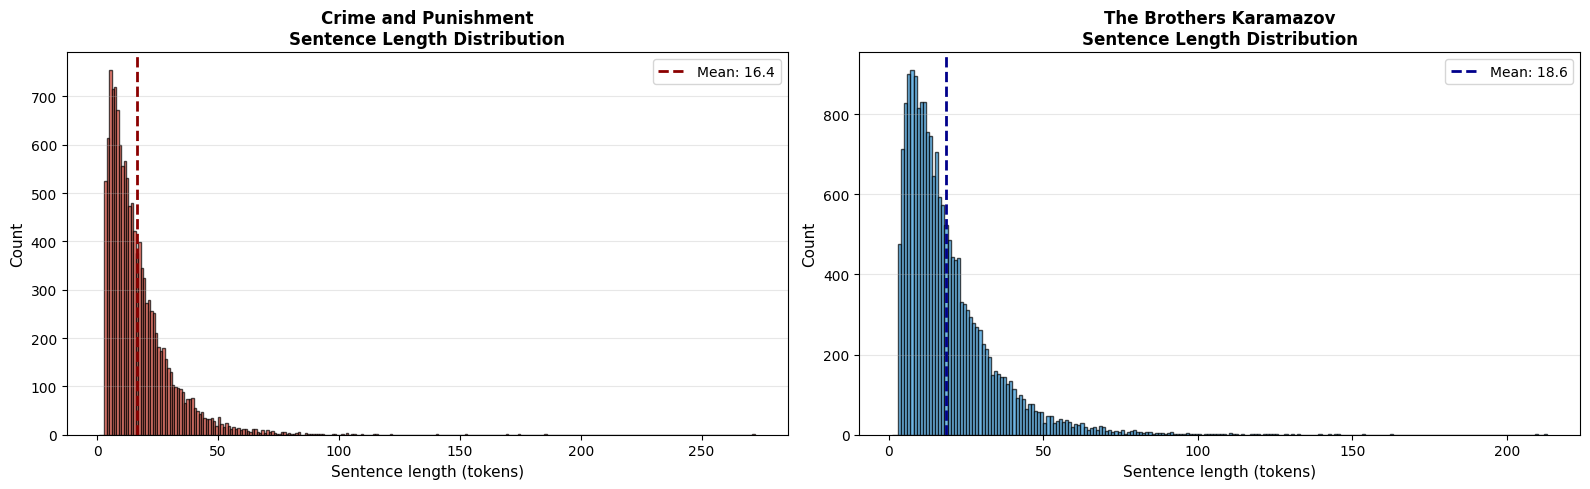

In [3]:
# Visualize sentence length distributions for both books
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Crime and Punishment
ax1 = axes[0]
ax1.hist(crime_tokens, bins=range(1, max(crime_tokens)+2), alpha=0.7, color='#e74c3c', edgecolor='black')
ax1.set_xlabel('Sentence length (tokens)', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_title("Crime and Punishment\nSentence Length Distribution", fontsize=12, fontweight='bold')
ax1.axvline(sum(crime_tokens)/len(crime_tokens), color='darkred', linestyle='--', linewidth=2, label=f'Mean: {sum(crime_tokens)/len(crime_tokens):.1f}')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# The Brothers Karamazov
ax2 = axes[1]
ax2.hist(brothers_tokens, bins=range(1, max(brothers_tokens)+2), alpha=0.7, color='#3498db', edgecolor='black')
ax2.set_xlabel('Sentence length (tokens)', fontsize=11)
ax2.set_ylabel('Count', fontsize=11)
ax2.set_title('The Brothers Karamazov\nSentence Length Distribution', fontsize=12, fontweight='bold')
ax2.axvline(sum(brothers_tokens)/len(brothers_tokens), color='darkblue', linestyle='--', linewidth=2, label=f'Mean: {sum(brothers_tokens)/len(brothers_tokens):.1f}')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

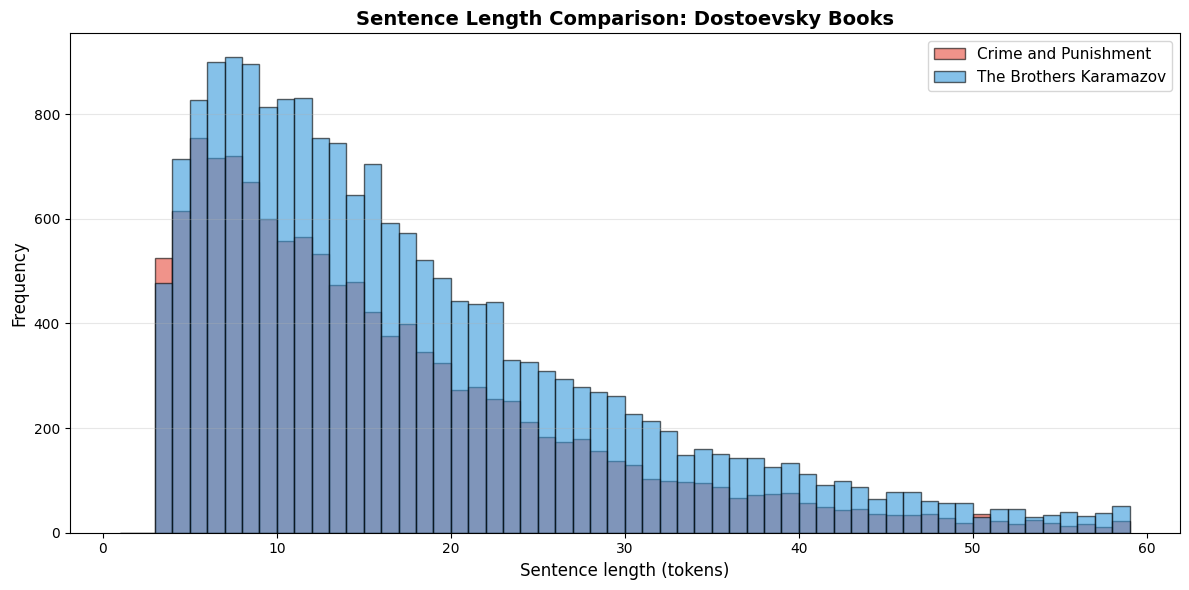


COMPARATIVE STATISTICS
Metric                         Crime and Punishment The Brothers Karamazov
----------------------------------------------------------------------
Mean sentence length                     16.45           18.63
Median sentence length                      13              15
Shortest sentence                            3               3
Longest sentence                           271             212


In [4]:
# Compare both books side by side
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(crime_tokens, bins=range(1, 60), alpha=0.6, color='#e74c3c', label='Crime and Punishment', edgecolor='black')
ax.hist(brothers_tokens, bins=range(1, 60), alpha=0.6, color='#3498db', label='The Brothers Karamazov', edgecolor='black')
ax.set_xlabel('Sentence length (tokens)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Sentence Length Comparison: Dostoevsky Books', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Statistical comparison
print("\n" + "="*70)
print("COMPARATIVE STATISTICS")
print("="*70)
print(f"{'Metric':<30} {'Crime and Punishment':>15} {'The Brothers Karamazov':>15}")
print("-"*70)
print(f"{'Mean sentence length':<30} {sum(crime_tokens)/len(crime_tokens):>15.2f} {sum(brothers_tokens)/len(brothers_tokens):>15.2f}")
print(f"{'Median sentence length':<30} {sorted(crime_tokens)[len(crime_tokens)//2]:>15} {sorted(brothers_tokens)[len(brothers_tokens)//2]:>15}")
print(f"{'Shortest sentence':<30} {min(crime_tokens):>15} {min(brothers_tokens):>15}")
print(f"{'Longest sentence':<30} {max(crime_tokens):>15} {max(brothers_tokens):>15}")

In [16]:
from sentence_transformers import SentenceTransformer, util
import torch

# Load the specific model you found
# This model is small, fast, and very effective for this task
model = SentenceTransformer('all-MiniLM-L6-v2')

print("Sentence-transformer model loaded successfully.")

c:\Users\moham\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


Sentence-transformer model loaded successfully.


In [17]:
# 1. Use the 'crime_sents' list we created in cell [2]
# We only need to "embed" this list once.
print(f"Embedding {len(crime_sents)} sentences from Crime and Punishment...")

# Check if a GPU is available, otherwise use CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)

# Convert all sentences to vectors (embeddings)
crime_embeddings = model.encode(crime_sents, convert_to_tensor=True, show_progress_bar=True)

print("Embeddings created.")

# 2. Define our semantic query
# Notice we are not using keywords like "Raskolnikov" or "murder"
query = 'A man is feeling sick and guilty about his actions.'

# 3. Convert the query to a vector
query_embedding = model.encode(query, convert_to_tensor=True)

# 4. Find the top 5 most similar sentences in the book
# We use cosine similarity to find the highest-scoring matches
search_hits = util.semantic_search(query_embedding, crime_embeddings, top_k=5)

# 5. Display the results
print(f"\n--- Semantic Search Results for query: '{query}' ---")

for hit in search_hits[0]:
    print(f"\nScore: {hit['score']:.4f}")
    print(f"Sentence: {crime_sents[hit['corpus_id']]}")

Embedding 12802 sentences from Crime and Punishment...


Batches: 100%|██████████| 401/401 [01:34<00:00,  4.24it/s]

Embeddings created.

--- Semantic Search Results for query: 'A man is feeling sick and guilty about his actions.' ---

Score: 0.5973
Sentence: And each time he passed,
the young man had a sick, frightened feeling,
which made him scowl and feel ashamed

Score: 0.5852
Sentence: One feels ashamed and
goes back to a man

Score: 0.5296
Sentence: After having committed the
crime, he goes through a series of fevered incidents
with friends and family, during which his delirium
reveals a schizophrenic man whose various personali-
ties battle one another

Score: 0.5229
Sentence: His illness then,
all his strange actions

Score: 0.5192
Sentence: A man who has suffered
distress and annoyance as you did yesterday and who
yet can sympathise with the misery of others, such a
man


In [18]:
from sklearn.cluster import KMeans
import numpy as np

print("Clustering the 12,802 sentence embeddings into 10 topics...")

# 1. Define the number of clusters (topics) we want to find
num_clusters = 10

# 2. Convert embeddings to a standard numpy array (which K-Means expects)
# .cpu() is important in case the embeddings were on a GPU
corpus_embeddings_np = crime_embeddings.cpu().numpy()

# 3. Initialize and run the K-Means algorithm
# We use 'n_init="auto"' for the modern default
clustering_model = KMeans(n_clusters=num_clusters, n_init="auto", random_state=42)
clustering_model.fit(corpus_embeddings_np)

# 4. Get the cluster ID for each sentence
cluster_assignment = clustering_model.labels_

print("Clustering complete.")

# 5. Store the sentences and their cluster assignments for review
clustered_sentences = [[] for i in range(num_clusters)]
for sentence_id, cluster_id in enumerate(cluster_assignment):
    clustered_sentences[cluster_id].append(crime_sents[sentence_id])

Clustering the 12,802 sentence embeddings into 10 topics...
Clustering complete.


In [19]:
import random

print("--- Example Sentences from Each Thematic Cluster ---")

# Display 5 random sentences from each cluster
for i in range(num_clusters):
    print(f"\n==================== CLUSTER {i+1} (Topic {i+1}) ====================")
    print(f"({len(clustered_sentences[i])} sentences in this cluster)")
    
    # Get 5 random samples
    random_samples = random.sample(clustered_sentences[i], min(5, len(clustered_sentences[i])))
    
    for j, sentence in enumerate(random_samples):
        print(f"  {j+1}. {sentence}")

--- Example Sentences from Each Thematic Cluster ---

==================== CLUSTER 1 (Topic 1) ====================
(1375 sentences in this cluster)
  1. bonds and now he sat
down to the table and counted over bundles of notes
  2. Even his depression had passed,
there was not a trace now of the energy with which he
had set out “to make an end of it all.” Complete apa-
thy had succeeded to it
  3. These facts
made an impression in his favour
  4. The plot erupts through the eyes of the misanthropic
young protagonist who has endured a life steeped in
poverty
  5. He seemed to be trying in
that latter stage to escape from a full and clear
understanding of his position

==================== CLUSTER 2 (Topic 2) ====================
(1270 sentences in this cluster)
  1. “I won’t lose sight of him
  2. ”
    “But I say
  3. Who was it came before?”
   “That was the day before yesterday, I venture to
say, if you please, sir
  4. “Please sit down
  5. “Get in, all get in,” cried Mikolka, “she 

C:\Users\moham\AppData\Local\Temp\ipykernel_16796\1383473225.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topic_labels, y=cluster_counts, palette="viridis")


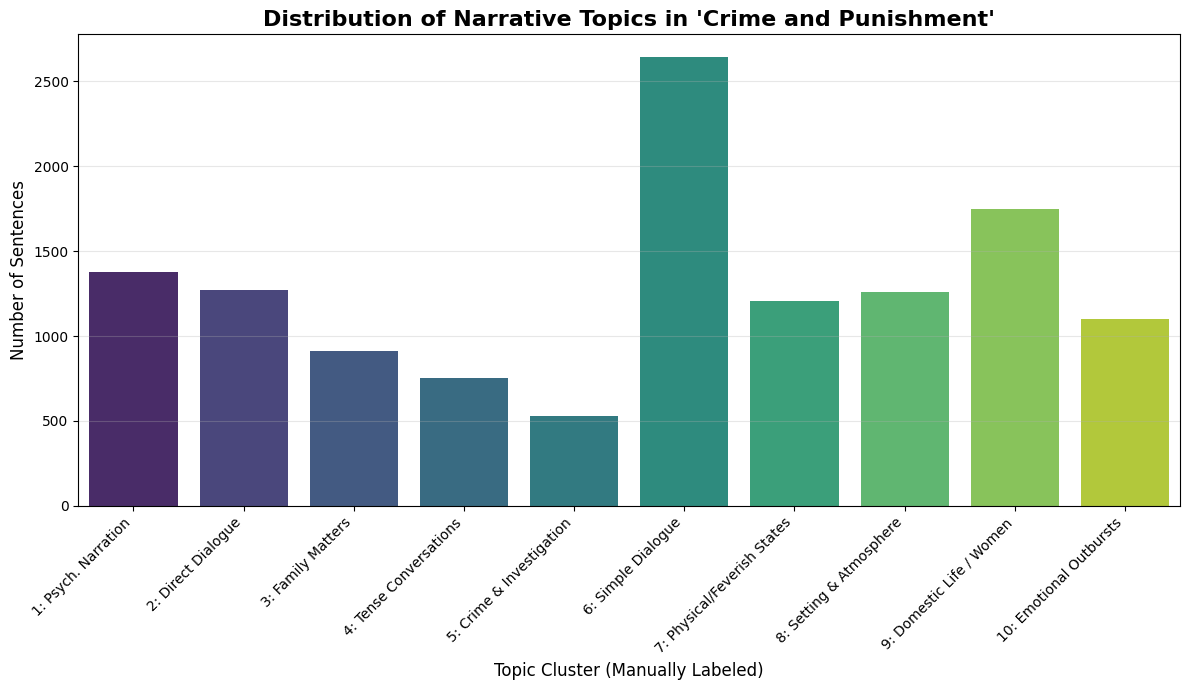

In [22]:
# 1. Our human-readable topic labels
topic_labels = [
    "1: Psych. Narration",
    "2: Direct Dialogue",
    "3: Family Matters",
    "4: Tense Conversations",
    "5: Crime & Investigation",
    "6: Simple Dialogue",
    "7: Physical/Feverish States",
    "8: Setting & Atmosphere",
    "9: Domestic Life / Women",
    "10: Emotional Outbursts"
]

# 2. Re-calculate the counts (same as before)
cluster_counts = [len(c) for c in clustered_sentences]

# 3. Plot the final, descriptive graph
plt.figure(figsize=(12, 7))
sns.barplot(x=topic_labels, y=cluster_counts, palette="viridis")

plt.title("Distribution of Narrative Topics in 'Crime and Punishment'", fontsize=16, fontweight='bold')
plt.xlabel("Topic Cluster (Manually Labeled)", fontsize=12)
plt.ylabel("Number of Sentences", fontsize=12)
plt.xticks(rotation=45, ha='right') # ha='right' aligns the labels better
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# 1. Use the 'brothers_sents' list
print(f"Embedding {len(brothers_sents)} sentences from The Brothers Karamazov...")

# 2. Embed the sentences and create a NEW variable for the embeddings
brothers_embeddings = model.encode(brothers_sents, convert_to_tensor=True, show_progress_bar=True)

print("Embeddings created.")

# 3. Define a new query (or use the same one!)
# Let's try a query more specific to this book
query = 'A man struggles with his faith and the existence of God.'

# 4. Convert the query to a vector
query_embedding = model.encode(query, convert_to_tensor=True)

# 5. Find the top 5 most similar sentences
# Make sure to search 'brothers_embeddings'
search_hits = util.semantic_search(query_embedding, brothers_embeddings, top_k=5)

# 6. Display the results
print(f"\n--- Semantic Search Results for query: '{query}' ---")

for hit in search_hits[0]:
    # Make sure to print from 'brothers_sents'
    print(f"\nScore: {hit['score']:.4f}")
    print(f"Sentence: {brothers_sents[hit['corpus_id']]}")

Embedding 18790 sentences from The Brothers Karamazov...


Batches: 100%|██████████| 588/588 [02:48<00:00,  3.49it/s]

Embeddings created.

--- Semantic Search Results for query: 'A man struggles with his faith and the existence of God.' ---

Score: 0.5709
Sentence: “From what specially?”

			“I suffer﻿ ﻿… from lack of faith.”

			“Lack of faith in God?”

			“Oh, no, no

Score: 0.5664
Sentence: The spiritual world, the higher part of man’s being is rejected altogether, dismissed with a sort of triumph, even with hatred

Score: 0.5606
Sentence: One who does not believe in God will not believe in God’s people

Score: 0.5464
Sentence: He loved his God and believed in Him steadfastly, though he was suddenly murmuring against Him

Score: 0.5451
Sentence: As he’s an honorable person there’s a hidden indignation boiling within him at having to pretend and affect holiness.”

			“But, of course, he believes in God.”

			“Not a bit of it


In [24]:
print(f"Clustering the {len(brothers_sents)} sentence embeddings into 10 topics...")

# 1. Use the 'brothers_embeddings'
corpus_embeddings_np = brothers_embeddings.cpu().numpy()

# 2. Run the K-Means algorithm
clustering_model = KMeans(n_clusters=num_clusters, n_init="auto", random_state=42)
clustering_model.fit(corpus_embeddings_np)

# 3. Get the cluster ID for each sentence
cluster_assignment = clustering_model.labels_

print("Clustering complete.")

# 4. Create a NEW variable to store the clustered sentences
brothers_clustered_sentences = [[] for i in range(num_clusters)]
for sentence_id, cluster_id in enumerate(cluster_assignment):
    # Use 'brothers_sents' as the source
    brothers_clustered_sentences[cluster_id].append(brothers_sents[sentence_id])

Clustering the 18790 sentence embeddings into 10 topics...
Clustering complete.


In [25]:
print("--- Example Sentences from Each Thematic Cluster (The Brothers Karamazov) ---")

# Display 5 random sentences from each cluster
for i in range(num_clusters):
    print(f"\n==================== BROTHERS: CLUSTER {i+1} ====================")
    # Use the new 'brothers_clustered_sentences' variable
    print(f"({len(brothers_clustered_sentences[i])} sentences in this cluster)")
    
    random_samples = random.sample(brothers_clustered_sentences[i], min(5, len(brothers_clustered_sentences[i])))
    
    for j, sentence in enumerate(random_samples):
        print(f"  {j+1}. {sentence}")

--- Example Sentences from Each Thematic Cluster (The Brothers Karamazov) ---

==================== BROTHERS: CLUSTER 1 ====================
(1859 sentences in this cluster)
  1. He rarely read aloud, only perhaps in Lent
  2. It’s long﻿—eight centuries﻿—since we have been on his side and not on Thine
  3. He helped, evidently alarmed and upset
  4. He seemed to hear again Father Zossima’s words, foretelling his approaching end
  5. A nightmare of ideas and sensations filled his soul

==================== BROTHERS: CLUSTER 2 ====================
(1094 sentences in this cluster)
  1. What is this babe?”

			“It must be Rakitin, who’s been going to see him lately,” smiled Alyosha, “though﻿ ﻿… that’s not Rakitin’s doing
  2. The woman of the house and Foma too, if he were here, might be loyal to his brother and obey his instructions, and so refuse to let Alyosha come into the garden, or might warn Dmitri that he was being sought and inquired for
  3. I should be glad of your kind interest

C:\Users\moham\AppData\Local\Temp\ipykernel_16796\1727307208.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topic_labels, y=cluster_counts, palette="viridis_r") # Using a reverse palette


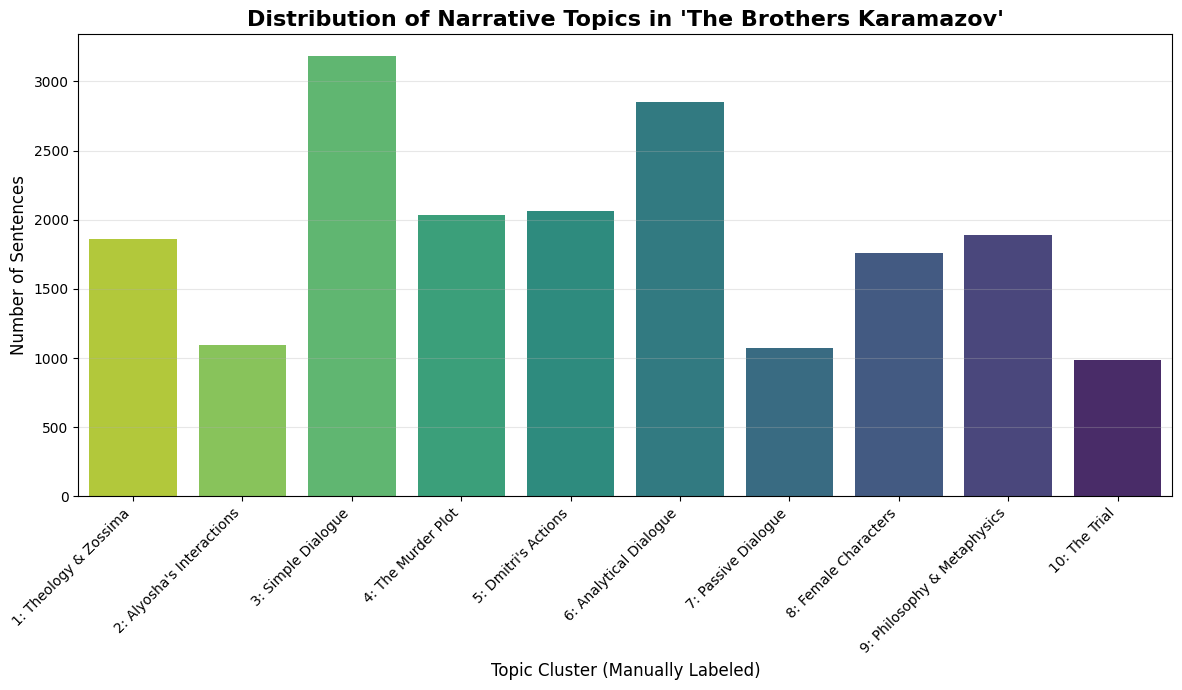

In [26]:
# 1. Our human-readable topic labels for *The Brothers Karamazov*
topic_labels = [
    "1: Theology & Zossima",
    "2: Alyosha's Interactions",
    "3: Simple Dialogue",
    "4: The Murder Plot",
    "5: Dmitri's Actions",
    "6: Analytical Dialogue",
    "7: Passive Dialogue",
    "8: Female Characters",
    "9: Philosophy & Metaphysics",
    "10: The Trial"
]

# 2. Get the counts from the 'brothers' cluster variable
#    *** This is the only line of code that is different from the C&P plot ***
cluster_counts = [len(c) for c in brothers_clustered_sentences]


# 3. Plot the final, descriptive graph
plt.figure(figsize=(12, 7))
sns.barplot(x=topic_labels, y=cluster_counts, palette="viridis_r") # Using a reverse palette

plt.title("Distribution of Narrative Topics in 'The Brothers Karamazov'", fontsize=16, fontweight='bold')
plt.xlabel("Topic Cluster (Manually Labeled)", fontsize=12)
plt.ylabel("Number of Sentences", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()